# Homework (15 points)

In this homework we train Sound Event Detection model.

Dataset: https://disk.yandex.ru/d/NRpDIp4jg2ODqg

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import requests
import tqdm.notebook as tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import urllib

# implementation of Dataset for given data|
import dataset

from IPython.display import clear_output

%matplotlib inline

In [3]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from tarfile import TarFile
import tarfile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/NRpDIp4jg2ODqg'
dst_path = '/home/jupyter/mnt/datasets/sound_event_detection/dataset/' # if we make the Datasphere datasets work
dst_path = './dataset/'

final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']

# if you aren't in the Datasphere
# !wget -O data.tar.gz  "{download_url}"
# !tar -xf data.tar.gz 

# otherwise
response = requests.get(download_url)
io_bytes = BytesIO(response.content)
tar = tarfile.open(fileobj=io_bytes, mode='r:gz')
tar.extractall(path=dst_path)


In [2]:
dst_path = './dataset/'
DEVICE = 'cuda' # also you can use "cuda" for gpu and "mps" for apple silicon
DATADIR = dst_path + 'data'
LOADER_WORKERS = 4

In [3]:
import random

class AddWhiteNoise(nn.Module):
    def __init__(self, prob=0.5, snr_db_bounds=(30, 40)):
        super().__init__()
        self.prob = prob
        self.snr_db_bounds = snr_db_bounds

    def forward(self, waveform):
        rnd = random.uniform(0, 1)
        if rnd > self.prob:
            return waveform
        snr_db = random.uniform(*self.snr_db_bounds)
        signal_power = torch.mean(waveform**2, dim=-1, keepdim=True)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = torch.randn_like(waveform) * torch.sqrt(noise_power)

        return waveform + noise
    
    
class Pitch(nn.Module):
    def __init__(self, prob=0.2, num_mels_up_bounds=(-5, 5)):
        super().__init__()
        self.nmu_bounds = num_mels_up_bounds
        self.prob = prob

    def forward(self, mel):
        # Your code here
        rnd = random.uniform(0, 1)
        if rnd > self.prob:
            return mel
        
        nmu = random.randint(*self.nmu_bounds)

        if nmu > 0:
            new_mel = torch.roll(mel, nmu, dims=1)
            new_mel[:, :nmu] = 0
        elif nmu < 0:
            new_mel = torch.roll(mel, nmu, dims=1)
            new_mel[:, nmu:] = 0
        else:
            return mel
        
        return new_mel
    
    
    
class MyTimeStretch(torchaudio.transforms.TimeStretch):
    def __init__(self, prob=0.7, bounds=(0.8, 1.2)):
        super().__init__(n_freq=201)
        self.prob = prob
        self.bounds = bounds

    def forward(self, spec):
        rnd = random.uniform(0, 1)
        if rnd > self.prob:
            return spec
        rate = random.uniform(*self.bounds)


        return super().forward(spec, rate)
    

In [4]:
# FBANK 80 by default, but you can choose something else
FEATS = 80
# transform_train = nn.Sequential(
#     AddWhiteNoise(),
#     torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
#     Pitch(),
#     torchaudio.transforms.AmplitudeToDB(),
#     # augmentation(1)
# )
transform_train = nn.Sequential(
    AddWhiteNoise(),
    # torchaudio.transforms.Spectrogram(power=None),
    # MyTimeStretch(),
    # torchaudio.transforms.MelScale(n_mels=FEATS),
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
    Pitch(),
    torchaudio.transforms.TimeMasking(time_mask_param=80, p=0.2),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=15),
    torchaudio.transforms.AmplitudeToDB(),
    # augmentation(1)
)
transform_test = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),    
    torchaudio.transforms.AmplitudeToDB()
)
trainset = dataset.Dataset('train', DATADIR, transform_train)
testset = dataset.Dataset('eval', DATADIR, transform_test)
N_CLASSES = trainset.classes()

### Eval part (1 point)

Write balanced accuracy:
$$BAcc = \frac{1}{classes}\sum_{c = 1}^{classes} \frac{\sum_i^n I(y_i = p_i = c)}{\sum_i^n I(y_i = c)}$$

Where:
- $y_i$ -- target class for $i$ element
- $p_i$ -- predicted class for $i$ element

In [5]:
# Get list of pairs (target_class, predicted_class)
from collections import defaultdict
def balanced_accuracy(items: list[tuple[int, int]]) -> float:
    d = defaultdict(int)
    d_all = defaultdict(int)
    for target, predict in items:
        d_all[target] += 1
        if target == predict:
            d[target] += 1
    num_classes = 0
    numer = 0
    for cl in d_all:
        num_classes += 1
        numer += d[cl] / d_all[cl]
    return numer / num_classes


        

In [47]:
assert np.isclose(balanced_accuracy([(0, 0), (0, 0), (1, 1)]), 1.0)
assert np.isclose(balanced_accuracy([(0, 1), (1, 0)]), 0.0)
assert np.isclose(balanced_accuracy([(0, 0), (0, 0), (1, 0)]), 0.5)
assert np.isclose(balanced_accuracy([(0, 0), (1, 1), (0, 0), (0, 0), (1, 0), (0, 1)]), 0.625)
assert np.isclose(balanced_accuracy([(1, 1), (0, 1), (2, 2)]), 0.66666666666666)

### Train part (14 points)

Train some model with test accuracy > 0.5

You can train any model you want. The only limitations are 
    1) it must be trained from scratch on the data provided in the task
    2) it must have less than 5M parameters

For example you can choose model from:
- DNN
- CNN 1d
- CNN 2d
- Transformer
- RNN
- mixes of given models

You can draw inspiration from the big models and build your own small model from scratch.

Hints:
- No need to train large models for this task. 5 million parameters is much more than you need.
- The score can be achieved by models with less than 100K params
- Take the feature dimension into account
- Monitor overfitting, try to add Augmentation, Dropout, BatchNorm, L1/L2-Regulatization or something else.
- Score of 0.35 is easily achievable by CNN 1d
- Use poolings or strides to reduce time-dimenstion. It is better to reduce the dimension gradually rather than at the end.
- Pay attention to the time dimension at the end of the network. How big is the receptive field of the network?
- Try different features (mel-spec, log-mel-spec, mfcc)
- You may need more than 10 epochs. One would would consider 20-30 epochs as a reasonable estimate
- You may need to use smaller batches)

P.S. Points can be subtracted for unclear training charts. Keep all the experiments that you've run in the notebook.

PP.S. It is sufficient for your model to beat the threshold once. We imagine a) there is a hidden best checkpoint save option and b) that the distribution of the test used to monitor the training is identical to the distribution of all possible tests)

PPP.S. A partial score will be awarded for a test accuracy < 0.5. Score of 0.35 is easily achievable by CNN 1d

PPPP.S. Add log to Melspectrogram in torchaudio.transform

In [12]:
def get_num_params(model):
    result = 0
    for param in model.parameters():
        result += param.numel()
    return result


def stage(
    model: nn.Module,
    data: dataset.Dataset,
    opt: optim.Optimizer,
    batch_size: int = 256,
    train: bool = True
):
    loader = torch_data.DataLoader(
        data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=LOADER_WORKERS,
        collate_fn=dataset.collate_fn
    )
    if train:
        model.train()
    else:
        model.eval()
    loss_sum, batches = 0.0, 0
    pred_pairs = []
    for X, Y in tqdm.tqdm(loader):
        # pred = model.forward(X.to(DEVICE))
        # loss = F.cross_entropy(pred.squeeze(), Y.squeeze().to(DEVICE))
        pred = model.forward(X.unsqueeze(1).to(DEVICE))
        loss = F.cross_entropy(pred, Y.squeeze().to(DEVICE))

        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()
        loss_sum += loss.item()
        batches += 1
        with torch.no_grad():
            pred_pairs.extend(zip(
                Y.data.numpy().reshape(-1),
                torch.argmax(pred, dim=1).cpu().data.numpy().reshape(-1)
            ))
    return loss_sum / batches, balanced_accuracy(pred_pairs)


def train(
    model: nn.Module,
    opt,
    batch_size: int = 128,
    epochs: int = 25,
):
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    for epoch in range(epochs):
        train_loss, train_acc = stage(model, trainset, opt, batch_size=batch_size)
        test_loss, test_acc = stage(model, testset, opt, batch_size=batch_size, train=False)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train')
        axis[0].plot(np.arange(1, epoch + 2), test_losses, label='test')
        axis[1].plot(np.arange(1, epoch + 2), train_accs, label='train')
        axis[1].plot(np.arange(1, epoch + 2), test_accs, label='test')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='Accuracy')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}.')
        print(f'Train loss {train_loss}. Train accuracy {train_acc}.')
        print(f'Test loss {test_loss}. Test accuracy {test_acc}')

In [32]:
    
class Model(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv1d(in_channels=80, out_channels=64, kernel_size=5, padding='same'),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(in_channels=64, out_channels=32, kernel_size=5, padding='same'),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=5, padding='same'),
            nn.BatchNorm1d(16),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )
        self.fl = nn.Flatten()
        self.fin_lin = nn.Linear(16, N_CLASSES)
        
        
        
       
    def forward(self, X):
        X = self.sequential(X)
        # print(X.shape)
        res, _ = torch.max(X, dim=-1)
        # res, _ = self.lstm(torch.transpose(X, 1, 2))
        # print(res.shape)
        # res = F.softmax(self.fin_lin(self.fl(res[:, -1, :])), dim=-1)
        res = F.softmax(self.fin_lin(self.fl(res)), dim=-1)

        return res

In [125]:
model = Model().to(DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters())

Number of parameters is  39246


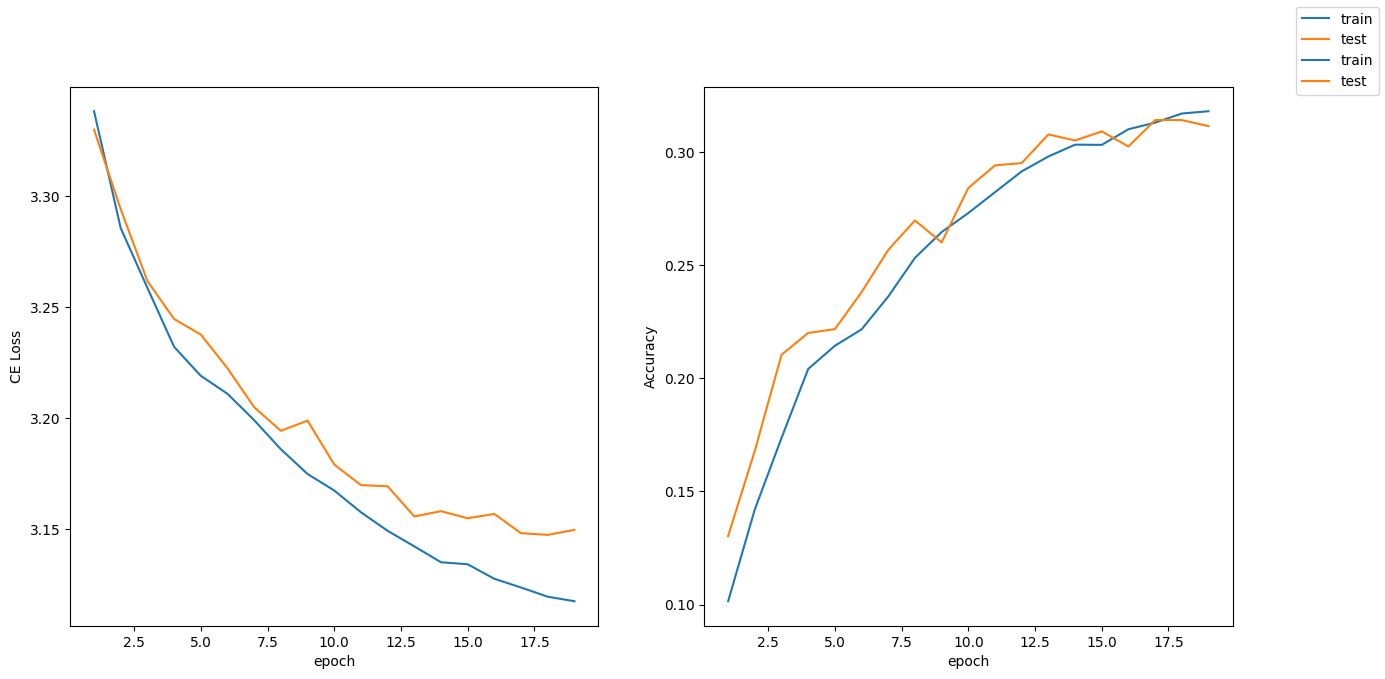

Epoch 19.
Train loss 3.1174817690035193. Train accuracy 0.31791590966289884.
Test loss 3.1496127347151437. Test accuracy 0.31133333333333335


  0%|          | 0/205 [00:00<?, ?it/s]

In [ ]:
train(model, opt)

In [ ]:
    
class Model2(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv1d(in_channels=80, out_channels=256, kernel_size=3, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=3, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
        )
        self.fl = nn.Flatten()
        self.fin_lin = nn.Linear(256, N_CLASSES)
        self.pool = nn.AdaptiveAvgPool1d(1)

        
        
       
    def forward(self, X):
        X = self.sequential(X)
        # print(X.shape)
        res = self.pool(X)
        res = F.softmax(self.fin_lin(res.squeeze(-1)), dim=-1)        # res, _ = self.lstm(torch.transpose(X, 1, 2))
        # print(res.shape)
        # res = F.softmax(self.fin_lin(self.fl(res[:, -1, :])), dim=-1)
        # res = F.softmax(self.fin_lin(self.fl(res)), dim=-1)

        return res

In [65]:
model = Model2().to(DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters())

Number of parameters is  859422


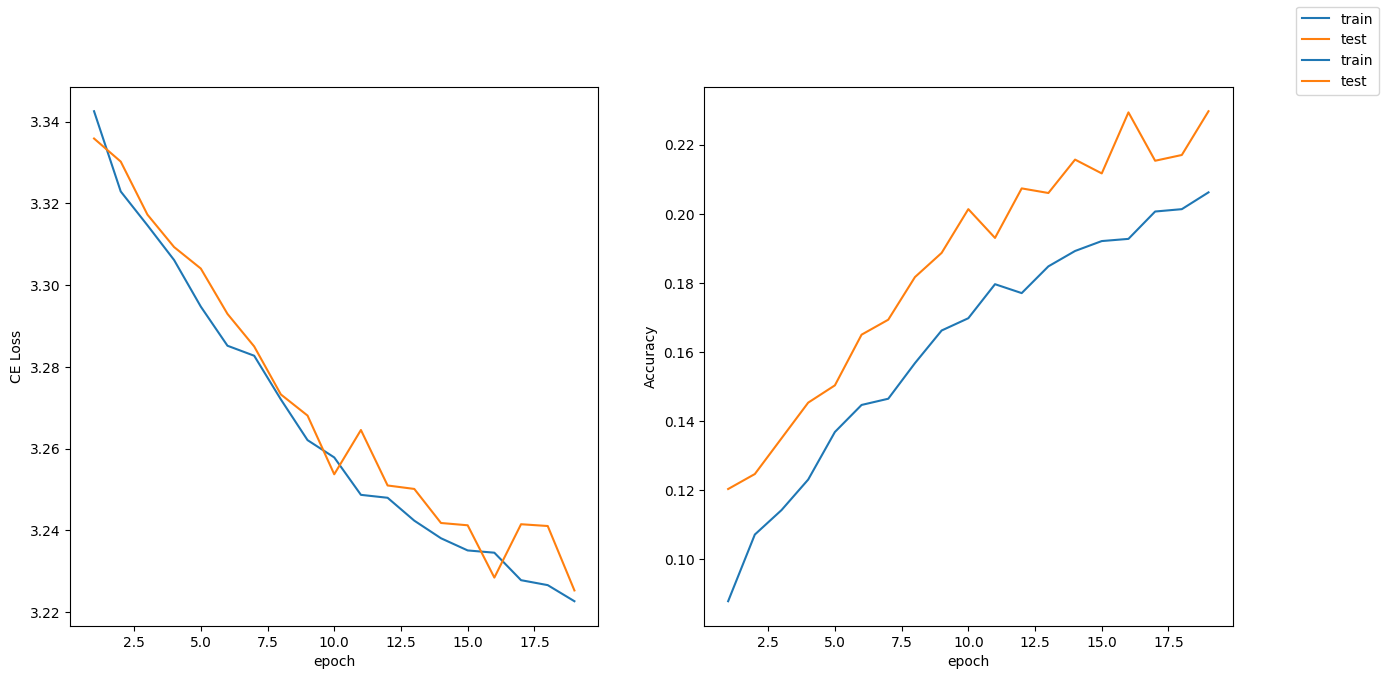

Epoch 19.
Train loss 3.2226530586800926. Train accuracy 0.206186647424853.
Test loss 3.225292464097341. Test accuracy 0.22966666666666666


  0%|          | 0/205 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
train(model, opt)

In [32]:
import math


class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)


class TransformerModel(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv1d(in_channels=80, out_channels=80, kernel_size=5, stride=2),
            nn.BatchNorm1d(80),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=80, out_channels=80, kernel_size=5, stride=2),
            nn.BatchNorm1d(80),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(in_channels=80, out_channels=80, kernel_size=5, stride=2),
            nn.BatchNorm1d(80),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(in_channels=80, out_channels=80, kernel_size=5, stride=2),
            nn.BatchNorm1d(80),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(in_channels=80, out_channels=80, kernel_size=5, stride=2),
            nn.BatchNorm1d(80),
            nn.ReLU(),
            # nn.MaxPool1d(kernel_size=2, stride=2),
        )
        self.tf = nn.Sequential(
            # nn.Linear(256, 128),
            PositionalEncoding(d_model=80),
            nn.TransformerEncoderLayer(d_model=80, nhead=4, dim_feedforward=256),
        )
        self.fin_lin = nn.Linear(80, N_CLASSES)
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        
       
    def forward(self, X):
        X = self.sequential(X)
        X = self.tf(torch.transpose(X, 1, 2))
        res = self.pool(torch.transpose(X, 1, 2))
        res = F.softmax(self.fin_lin(res.squeeze(-1)), dim=-1)
        return res

In [33]:
model = TransformerModel().to(DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters(), lr=1e-3)

Number of parameters is  231166


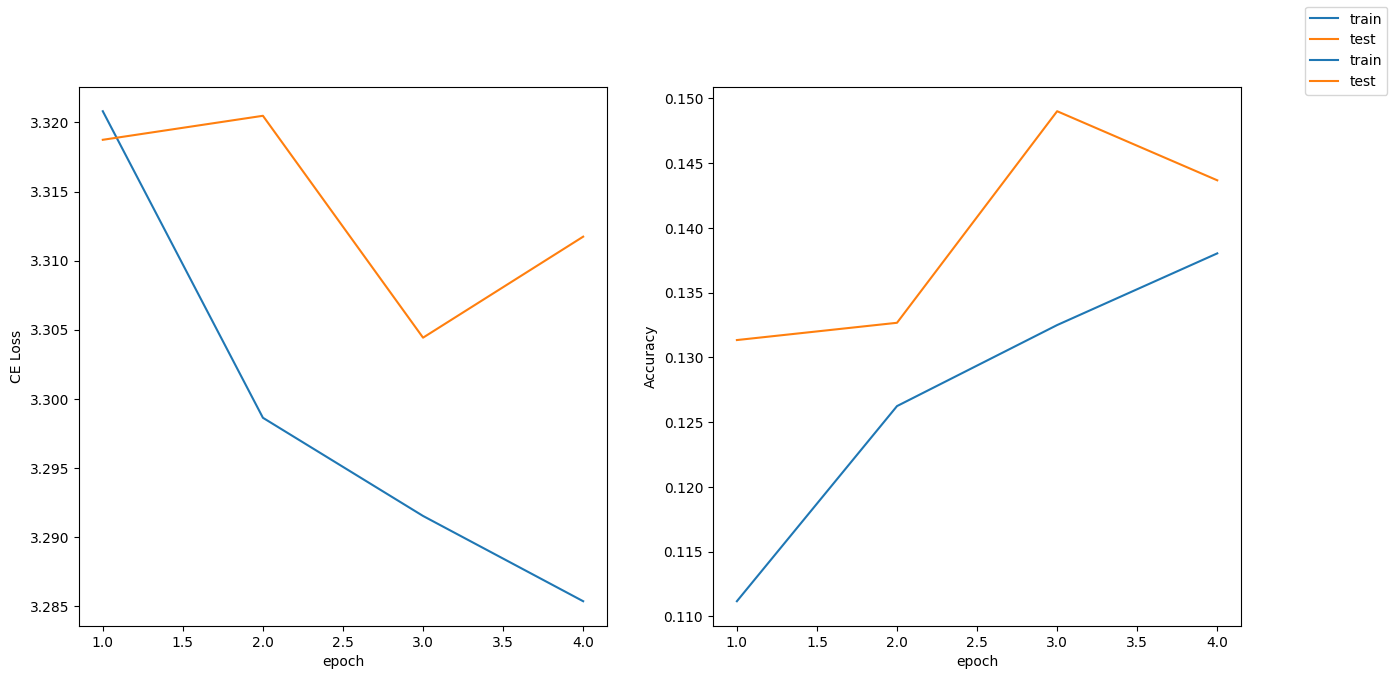

Epoch 4.
Train loss 3.2853384413370272. Train accuracy 0.13802536004822116.
Test loss 3.311731586853663. Test accuracy 0.14366666666666666


  0%|          | 0/205 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [34]:
train(model, opt)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv1d(in_channels=80, out_channels=128, kernel_size=5, padding='same'),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(in_channels=256, out_channels=256, kernel_size=5, padding='same'),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
        )
        self.fl = nn.Flatten()
        self.lstm = nn.LSTM(input_size=256, hidden_size=256, num_layers=1, batch_first=True)

        self.fin_lin = nn.Linear(256, N_CLASSES)
        
        
        
       
    def forward(self, X):
        X = self.sequential(X)
        res, _ = self.lstm(torch.transpose(X, 1, 2))
        res = F.softmax(self.fin_lin(self.fl(res[:, -1, :])), dim=-1)
        return res

In [91]:



class DepthwiseSeparable(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding='same'):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels, 
            kernel_size=kernel_size,
            stride=1, 
            padding=padding,
            groups=in_channels
        )
        self.pointwise = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1
        )
    
    def forward(self, X):
        return self.pointwise(self.depthwise(X))
    

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=False):
        super().__init__()
        padding = 'same'

        # self.conv1 = DepthwiseSeparable(in_channels, out_channels, kernel_size, stride, padding)
        # self.bn1 = nn.BatchNorm2d(out_channels)
        # self.relu = nn.ReLU(inplace=True)
        # self.conv2 = DepthwiseSeparable(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        # self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)  
        x = self.relu(self.bn1(self.conv1(x)))  
        x = self.bn2(self.conv2(x)) 
        x += residual  
        return self.relu(x)  
    
class GlobalAveragePool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        
    def forward(self, x):
        return torch.mean(x, dim=self.dim)
    
class DepthConvModel(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            # nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding='same'),
            # nn.BatchNorm2d(16),
            # nn.ReLU(),
            
            ResidualBlock(in_channels=1, out_channels=64, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            ResidualBlock(in_channels=64, out_channels=128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            ResidualBlock(in_channels=128, out_channels=128, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            ResidualBlock(in_channels=128, out_channels=256, kernel_size=3),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
        )
        self.pool = GlobalAveragePool(dim=(2,3))
        self.fin_lin = nn.Linear(256, N_CLASSES)
        
        
        
       
    def forward(self, X):
        X = self.sequential(X)
        # print(X.shape)
        # print(res.shape)
        res = F.softmax(self.fin_lin(self.pool(X)), dim=-1)

        return res

In [11]:
model = DepthConvModel().to(DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters(), lr=1e-3)

Number of parameters is  1491358


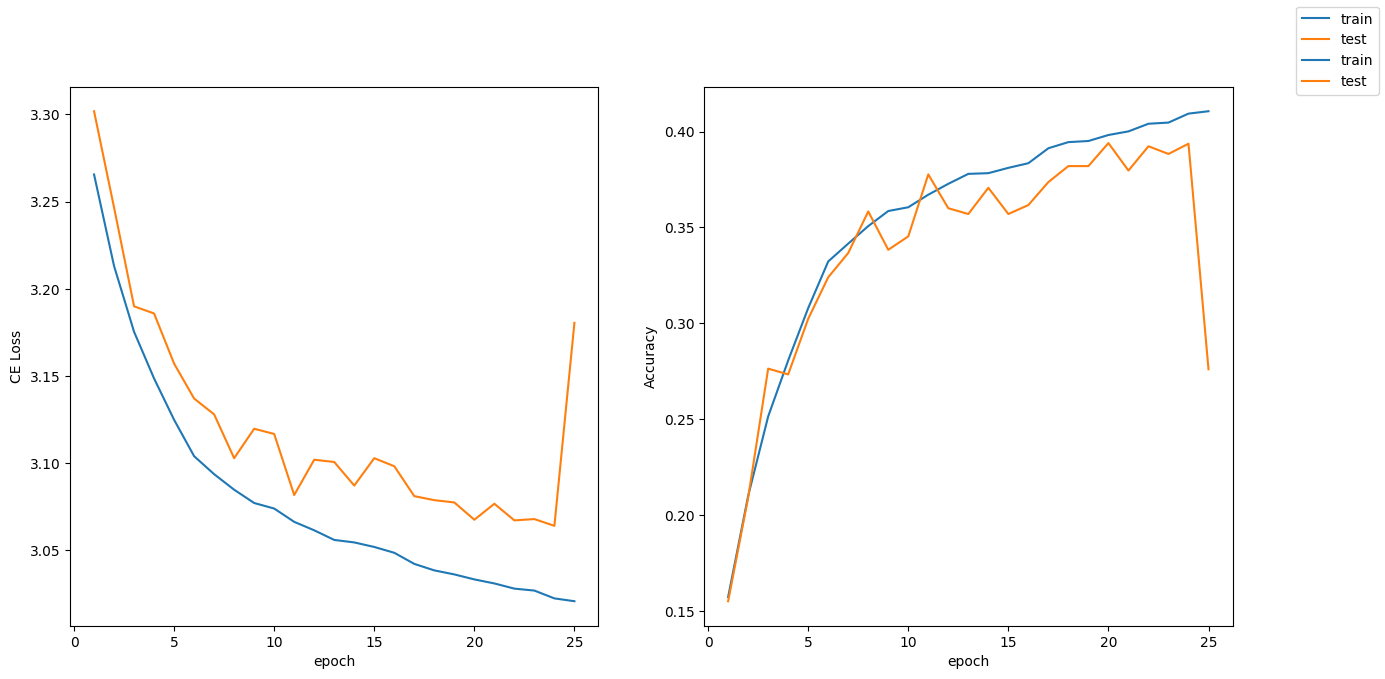

Epoch 25.
Train loss 3.0208759424163074. Train accuracy 0.4106192695157944.
Test loss 3.1805189748605094. Test accuracy 0.2760000000000001


In [12]:
train(model, opt)

## Господи я это сделал, хоть и суммарно за кучу эпох (там дальше я перезапускал на той же модели код трейна)

In [23]:
import torch.nn.functional as F

class ConvNextBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        
        self.depthwise_conv = nn.Conv2d(in_channels=dim, out_channels=dim, kernel_size=5, padding=2, groups=dim)  # depthwise conv 5x5, padding 2, dim->dim     
        self.norm = nn.BatchNorm2d(dim)       
        self.pointwise_conv1 = nn.Conv2d(in_channels=dim, out_channels=dim*4, kernel_size=1)  # 1x1 conv, dim -> dim*4  YOUR CODE
        self.activation = nn.GELU()       
        self.pointwise_conv2 = nn.Conv2d(in_channels=dim*4, out_channels=dim, kernel_size=1)  # 1x1 conv, 4*dim -> dim YOUR CODE

        
    def forward(self, x):
        input = x
        # YOUR CODE: sequentially apply to x: depthwise_conv + norm + pointwise_conv1 + activation + pointwise_conv2 + layer_scale
        x = self.depthwise_conv(x)
        x = self.norm(x)
        x = self.pointwise_conv1(x)
        x = self.activation(x)
        x = self.pointwise_conv2(x)
        return F.relu(input + x)



class ConvNextLikeModel(nn.Module):
    def __init__(self, in_dim=FEATS, out_dim=N_CLASSES):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding='same'),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            ConvNextBlock(16),
            nn.BatchNorm2d(16),
            nn.Conv2d(in_channels=16, out_channels=64, kernel_size=2, stride=2, padding=0), 

            ConvNextBlock(64),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=2, stride=2, padding=0),
            
            ConvNextBlock(128),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=2, stride=2, padding=0),
            
            # ConvNextBlock(256),
            # nn.BatchNorm2d(256),
            # nn.Conv2d(in_channels=256, out_channels=512, kernel_size=2, stride=2, padding=0),
            
            
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fin_lin = nn.Linear(256, N_CLASSES)
        
        
        
       
    def forward(self, X):
        X = self.sequential(X)
        # print(X.shape)
        # print(res.shape)
        res = F.softmax(self.fin_lin(self.pool(X).squeeze()), dim=-1)

        return res

In [24]:
model = ConvNextLikeModel().to(DEVICE)
print("Number of parameters is ", get_num_params(model))
opt = optim.AdamW(model.parameters(), lr=1e-3)


Number of parameters is  349454


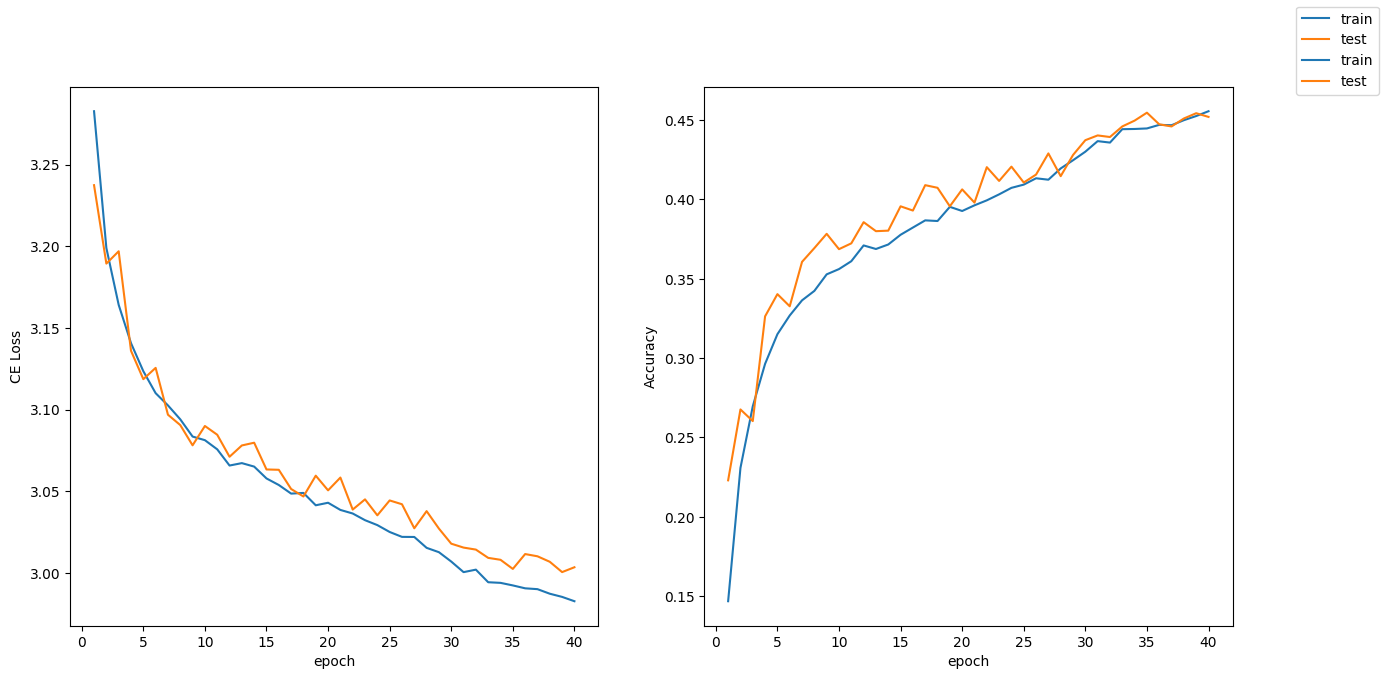

Epoch 40.
Train loss 2.9826975810818555. Train accuracy 0.4555873002136588.
Test loss 3.0034936467806497. Test accuracy 0.45199999999999996


In [25]:
train(model, opt, epochs = 40)

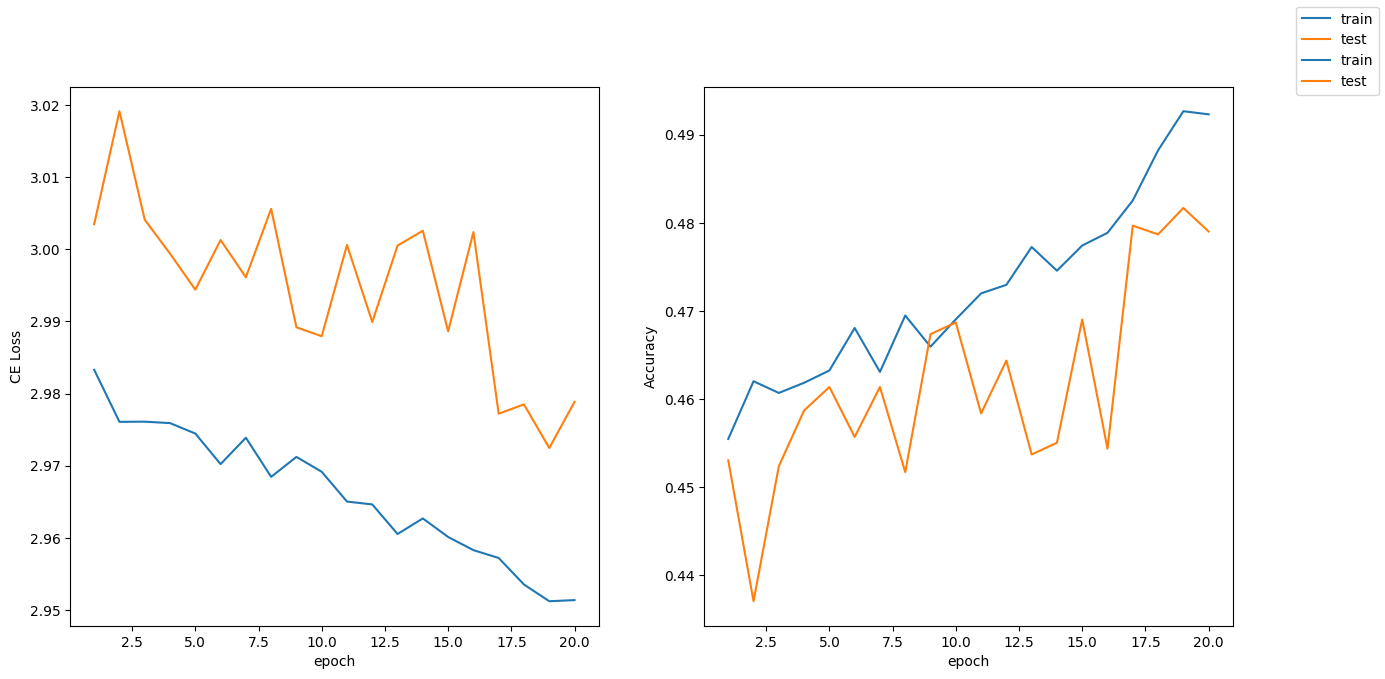

Epoch 20.
Train loss 2.951336836233372. Train accuracy 0.4923088841652496.
Test loss 2.978846182425817. Test accuracy 0.479


In [26]:
train(model, opt, epochs = 20)

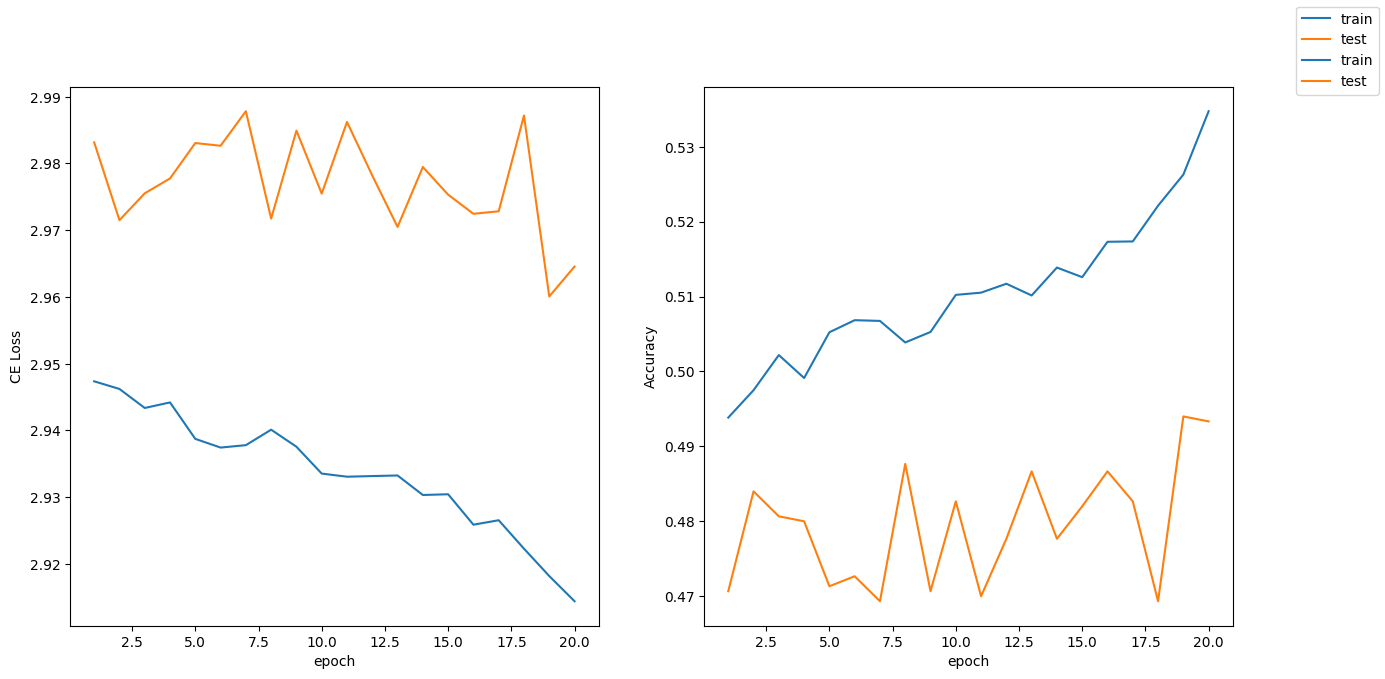

Epoch 20.
Train loss 2.9144107841863867. Train accuracy 0.5347345605515043.
Test loss 2.9645538528760276. Test accuracy 0.4933333333333334


In [27]:
train(model, opt, epochs = 20)

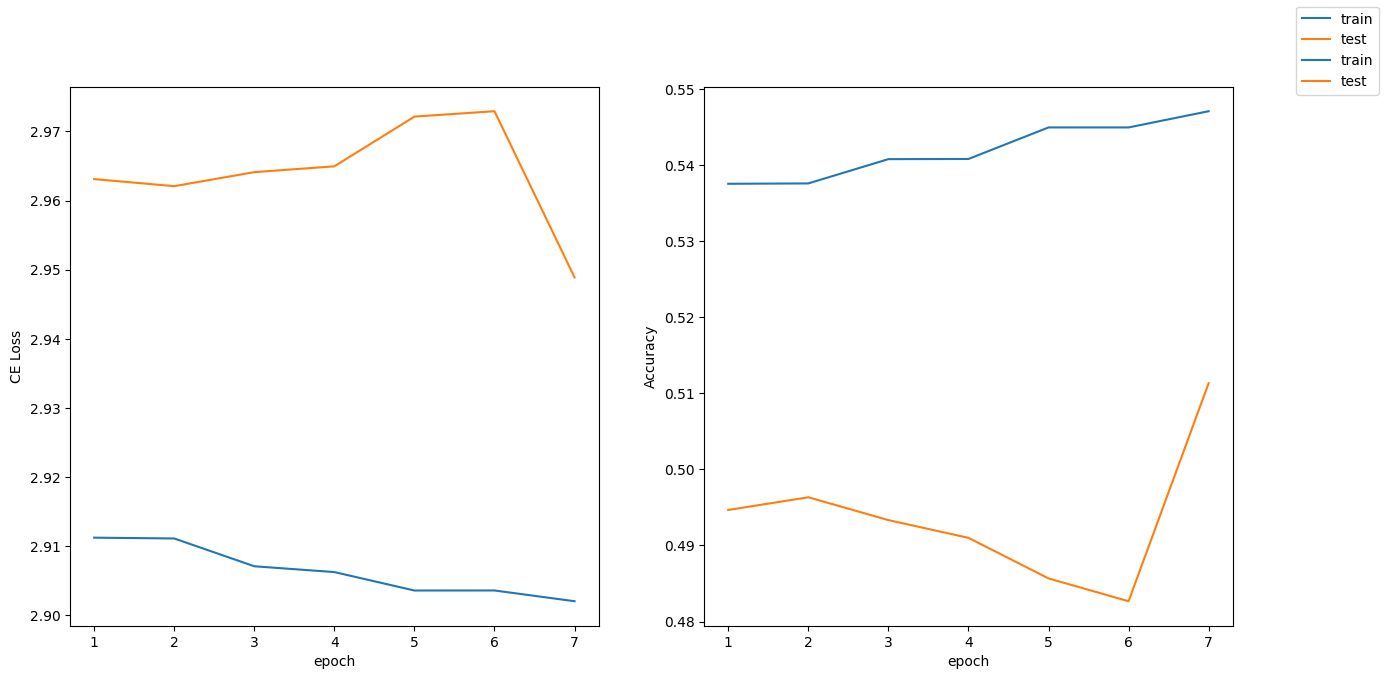

Epoch 7.
Train loss 2.9020357550644293. Train accuracy 0.5470930196990391.
Test loss 2.9488847851753235. Test accuracy 0.5113333333333334


  0%|          | 0/205 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [28]:
train(model, opt, epochs = 20)